In [106]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def custom_month_year_formatter(x, pos):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%Y')
    else:
        return date.strftime('%b')


matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8
matplotlib.rcParams['date.converter'] = 'concise'

LINEAGES = [
    'XBB.1.5.X',
    'XBB.1.16.X',
    'JN.1.X',
    'XEC.X',
]

In [107]:
cryptic_detects = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')

coverage = pd.read_csv('median_coverage_summary.tsv', sep='\t')
coverage['sample'] = coverage['sample'].str.split('.trimmed').str[0]

coverage = coverage.merge(cryptic_detects[['sample', 'collection_date']], on='sample', how='right')
coverage['week'] = pd.to_datetime(coverage['collection_date']).dt.to_period('W')
coverage = coverage.groupby('week')['MedianCoverage'].mean().reset_index()

cryptic_detects['collection_date'] = pd.to_datetime(cryptic_detects['collection_date'])
cryptic_detects['num_snps'] = cryptic_detects['nt_mutations'].apply(lambda x:len(x.split(' ')))
cryptic_detects = cryptic_detects[cryptic_detects['num_snps'] > 1]


cryptic_detects['week'] = cryptic_detects['collection_date'].dt.to_period('W')


cryptic_detects = cryptic_detects[cryptic_detects['num_clinical_detections'] < 1]

cryptic_detects = cryptic_detects.merge(coverage, on='week', how='left')
cryptic_detects = cryptic_detects.groupby(cryptic_detects['week']).agg({'collection_date': 'count', 'MedianCoverage': 'mean'}).rename(
    columns={'collection_date': 'cryptic_count'}).reset_index()

#Normalize by median coverage
cryptic_detects['cryptic_count'] = cryptic_detects['cryptic_count'] / cryptic_detects['MedianCoverage']

In [108]:
# Load viral load data
encina_viral_load = pd.read_csv('qPCR/Encina_sewage_qPCR.csv')
encina_viral_load['week'] = pd.to_datetime(encina_viral_load['Sample_Date']).dt.to_period('W')
encina_viral_load = encina_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

point_loma_viral_load = pd.read_csv('qPCR/PointLoma_sewage_qPCR.csv')
point_loma_viral_load['week'] = pd.to_datetime(point_loma_viral_load['Sample_Date']).dt.to_period('W')
point_loma_viral_load = point_loma_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

south_bay_viral_load = pd.read_csv('qPCR/SouthBay_sewage_qPCR.csv')
south_bay_viral_load['week'] = pd.to_datetime(south_bay_viral_load['Sample_Date']).dt.to_period('W')
south_bay_viral_load = south_bay_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

# Average viral loads across all sites
viral_load = encina_viral_load.merge(point_loma_viral_load, on='week', how='outer', suffixes=('_encina', '_point_loma'))
viral_load = viral_load.merge(south_bay_viral_load, on='week', how='outer')
viral_load = viral_load.rename(columns={'Mean viral gene copies/L': 'Mean viral gene copies/L_south_bay'})
viral_load['avg_viral_load'] = viral_load[['Mean viral gene copies/L_encina', 'Mean viral gene copies/L_point_loma', 'Mean viral gene copies/L_south_bay']].mean(axis=1)

cryptic_detects = cryptic_detects.merge(viral_load[['week', 'avg_viral_load']], on='week', how='left')

# Apply rolling average to smooth data
cryptic_detects['cryptic_count'] = cryptic_detects['cryptic_count'].rolling(window=4, min_periods=1).mean()
cryptic_detects['avg_viral_load'] = cryptic_detects['avg_viral_load'].rolling(window=4, min_periods=1).mean()

cryptic_detects['week_start'] = cryptic_detects['week'].dt.start_time
cryptic_detects

/tmp/ipykernel_1161133/384292071.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encina_viral_load['week'] = pd.to_datetime(encina_viral_load['Sample_Date']).dt.to_period('W')
/tmp/ipykernel_1161133/384292071.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  point_loma_viral_load['week'] = pd.to_datetime(point_loma_viral_load['Sample_Date']).dt.to_period('W')
/tmp/ipykernel_1161133/384292071.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  south_bay_viral_load['week'] = pd.to_datetime(south_bay_viral_load['Sample_Date']).dt.to_period('W')


,week,cryptic_count,MedianCoverage,avg_viral_load,week_start
0,2022-12-26/2023-01-01,0.001858,10763.000000,4.589962e+06,2022-12-26
1,2023-01-02/2023-01-08,0.015618,9190.468075,2.956268e+06,2023-01-02
2,2023-01-09/2023-01-15,0.016918,9427.417214,2.245477e+06,2023-01-09
3,2023-01-16/2023-01-22,0.016909,8056.547874,1.927677e+06,2023-01-16
4,2023-01-23/2023-01-29,0.021054,18711.134515,9.592755e+05,2023-01-23
...,...,...,...,...,...
93,2024-11-18/2024-11-24,0.028358,960.215909,2.410062e+06,2024-11-18
94,2024-11-25/2024-12-01,0.025318,1188.296296,2.941971e+06,2024-11-25
95,2024-12-02/2024-12-08,0.025853,452.344262,3.024290e+06,2024-12-02
96,2024-12-09/2024-12-15,0.007731,792.932203,3.164044e+06,2024-12-09


In [109]:
# Load point loma lineage prevalence data

thresh1 = 1
thresh2 = 40

lineage_prevalence = pd.read_csv('../data/PointLoma_sewage_seqs.csv')

# Get min and max dates for which each lineage appears above N% prevalence
lineage_prevalence['Date'] = pd.to_datetime(lineage_prevalence['Date'])
lineage_prevalence = lineage_prevalence[LINEAGES + ['Date']]
lineage_prevalence = lineage_prevalence[lineage_prevalence['Date'] >= '2023-01-01']
lineage_prevalence = lineage_prevalence[lineage_prevalence['Date'] <= '2024-12-31']


lineage_dates_thresh1 = {}
lineage_dates_thresh2 = {}
y = -7
for lineage in LINEAGES:
    dates_t1 = lineage_prevalence[lineage_prevalence[lineage] >= thresh1]['Date']
    dates_t2 = lineage_prevalence[lineage_prevalence[lineage] >= thresh2]['Date']
    lineage_dates_thresh1[lineage] = (dates_t1.min(), dates_t1.max(), y, lineage)
    lineage_dates_thresh2[lineage] = (dates_t2.min(), dates_t2.max(), y, lineage)
    y += 0.3

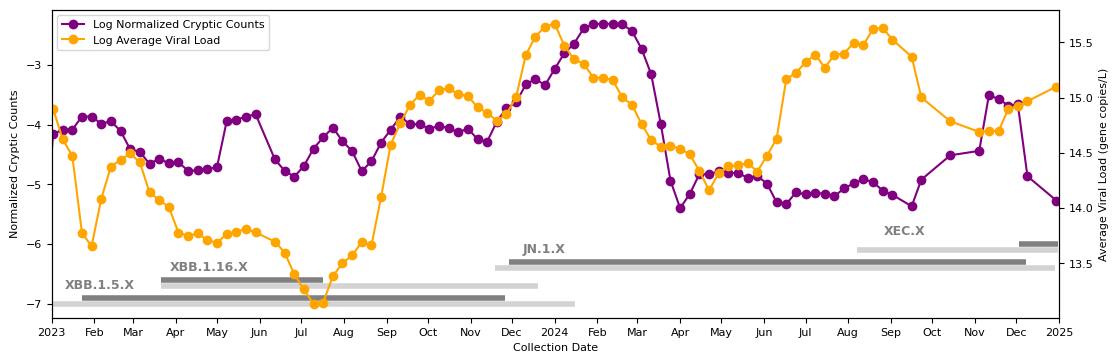

In [110]:
# Plot both cryptic counts and viral load over time with dual y-axes
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

# Plot main data
ax1.plot(
    cryptic_detects['week_start'], 
    np.log(cryptic_detects['cryptic_count']), 
    color='purple', marker='o', label='Log Normalized Cryptic Counts'
)
ax2.plot(
    cryptic_detects['week_start'], 
    np.log(cryptic_detects['avg_viral_load']), 
    color='orange', marker='o', label='Log Average Viral Load'
)

ax1.set_xlabel('Collection Date')
ax1.set_ylabel('Normalized Cryptic Counts')
ax2.set_ylabel('Average Viral Load (gene copies/L)')

# --- Add lineage prevalence bars with annotations ---
for start, end, y, label in lineage_dates_thresh1.values():
    # Draw horizontal line
    ax1.hlines(y, start, end, colors='lightgray', linewidth=4)

    ax1.text(
        start + pd.Timedelta(5, 'W'), y + 0.20,  # slight vertical offset
        label,
        ha='center', va='bottom',
        fontsize=9, color='gray',
        rotation=0, fontweight='bold'
    )

# --- Add lineage prevalence bars with annotations ---
for start, end, y, label in lineage_dates_thresh2.values():
    # Draw horizontal line
    ax1.hlines(y + 0.1, start, end, colors='gray', linewidth=4)


# --- Combine legends for line plots only ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# --- Format x-axis ---
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(plt.FuncFormatter(custom_month_year_formatter))

# --- Fit limits ---
ax1.set_xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2025-01-01'))

plt.savefig(
    'plots/cryptics_viral_load_logscale.pdf',
    transparent=True,
    bbox_inches='tight',
    dpi=300
)